# **Capstone 1**


## **Objective:**

This capstone program will focus on building predictive models and NLP solutions to:

- Analyze customer sentiment based on product reviews

- Predict product ratings using both text and structured data
- Detect spam or fake reviews by identifying unnatural language patterns
- Summarize product reviews to provide concise insights for buyers

By leveraging machine learning, NLP, and deep learning techniques, learners will address real-world challenges in customer feedback analysis, fraud detection, and AI-driven product insights.

### **Data Description:**

The dataset used in this capstone project is sourced from an e-commerce review platform, containing both structured and unstructured data:

**Section 1: Data analysis and preprocessing**

1- Data preprocessing with NumPy & Pandas

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

amazon_data= pd.read_csv('amazon_reviews.csv')

In [3]:
amazon_data.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,32158956,R1KKOXHNI8MSXU,B01KL6O72Y,24485154,Easy Tool Stainless Steel Fruit Pineapple Core...,Apparel,4,0,0,N,Y,★ THESE REALLY DO WORK GREAT WITH SOME TWEAKING ★,"These Really Do Work Great, But You Do Need To...",14-01-2013
1,US,2714559,R26SP2OPDK4HT7,B01ID3ZS5W,363128556,V28 Women Cowl Neck Knit Stretchable Elasticit...,Apparel,5,1,2,N,Y,Favorite for winter. Very warm!,I love this dress. Absolute favorite for winte...,04-03-2014
2,US,12608825,RWQEDYAX373I1,B01I497BGY,811958549,James Fiallo Men's 12-Pairs Low Cut Athletic S...,Apparel,5,0,0,N,Y,Great Socks for the money.,"Nice socks, great colors, just enough support ...",12-07-2015
3,US,25482800,R231YI7R4GPF6J,B01HDXFZK6,692205728,Belfry Gangster 100% Wool Stain-Resistant Crus...,Apparel,5,0,0,N,Y,Slick hat!,"I bought this for my husband and WOW, this is ...",03-06-2015
4,US,9310286,R3KO3W45DD0L1K,B01G6MBEBY,431150422,JAEDEN Women's Beaded Spaghetti Straps Sexy Lo...,Apparel,5,0,0,N,Y,I would do it again!,Perfect dress and the customer service was awe...,12-06-2015


In [4]:
## looking for missing values
amazon_drop= amazon_data.dropna()


In [5]:
## checking for null values
amazon_drop.isnull().sum()


,0
marketplace,0
customer_id,0
review_id,0
product_id,0
product_parent,0
product_title,0
product_category,0
star_rating,0
helpful_votes,0
total_votes,0


In [6]:
## Checking data info
amazon_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 511485 entries, 0 to 511484
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   marketplace        511485 non-null  object
 1   customer_id        511485 non-null  int64 
 2   review_id          511485 non-null  object
 3   product_id         511485 non-null  object
 4   product_parent     511485 non-null  int64 
 5   product_title      511485 non-null  object
 6   product_category   511485 non-null  object
 7   star_rating        511485 non-null  int64 
 8   helpful_votes      511485 non-null  int64 
 9   total_votes        511485 non-null  int64 
 10  vine               511484 non-null  object
 11  verified_purchase  511484 non-null  object
 12  review_headline    511481 non-null  object
 13  review_body        511182 non-null  object
 14  review_date        511428 non-null  object
dtypes: int64(5), object(10)
memory usage: 58.5+ MB


In [7]:
## Shape
amazon_data.describe()


,customer_id,product_parent,star_rating,helpful_votes,total_votes
count,5.114850e+05,5.114850e+05,511485.000000,511485.000000,511485.000000
mean,2.250692e+07,5.018923e+08,4.009547,1.168398,1.390375
std,1.647620e+07,2.898278e+08,1.344809,10.213873,10.651854
min,1.004700e+04,6.650000e+02,1.000000,0.000000,0.000000
25%,8.003163e+06,2.509600e+08,3.000000,0.000000,0.000000
50%,1.983469e+07,5.051607e+08,5.000000,0.000000,0.000000
75%,3.766577e+07,7.529867e+08,5.000000,1.000000,1.000000
max,5.309646e+07,9.999973e+08,5.000000,3675.000000,3714.000000


In [8]:
# Handle missing values in the review_body, star_rating, and verified_purchase columns
amazon_drop['review_body'] = amazon_drop['review_body'].fillna('')
amazon_drop['star_rating'] = amazon_drop['star_rating'].fillna(0)
amazon_drop['verified_purchase'] = amazon_drop['verified_purchase'].fillna('')

/tmp/ipykernel_1389/3127343499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['review_body'] = amazon_drop['review_body'].fillna('')
/tmp/ipykernel_1389/3127343499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['star_rating'] = amazon_drop['star_rating'].fillna(0)
/tmp/ipykernel_1389/3127343499.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the docu

In [9]:
# Convert review_date to datetime format and extract time-based trend
amazon_drop['review_date']= pd.to_datetime(amazon_drop['review_date'])
amazon_drop['review_time']= amazon_drop['review_date'].dt.time

/tmp/ipykernel_1389/2976687927.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  amazon_drop['review_date']= pd.to_datetime(amazon_drop['review_date'])
/tmp/ipykernel_1389/2976687927.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['review_date']= pd.to_datetime(amazon_drop['review_date'])
/tmp/ipykernel_1389/2976687927.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amaz

In [10]:
# Clean and transform review_body to remove HTML tags and unnecessary characters
amazon_drop['review_body'] = amazon_drop['review_body'].str.replace(
    r'<.*?>', '', regex=True
)
amazon_drop['review_body'] = amazon_drop['review_body'].str.replace(
    r'[^a-zA-Z\s]', '', regex=True
)


/tmp/ipykernel_1389/291883094.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['review_body'] = amazon_drop['review_body'].str.replace(
/tmp/ipykernel_1389/291883094.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['review_body'] = amazon_drop['review_body'].str.replace(


### **Exploratory Data Analysis (EDA) with Pandas & visualization libraries**

In [ ]:
# Compute summary statistics for ratings and helpful votes
rating_stats = amazon_drop['star_rating'].describe()
helpful_stats = amazon_drop['helpful_votes'].describe()

print("Rating Statistics:")
print(rating_stats)
print("\nHelpful Votes Statistics:")
print(helpful_stats)



Rating Statistics:
count    1.048098e+06
mean     4.023250e+00
std      1.331489e+00
min      1.000000e+00
25%      3.000000e+00
50%      5.000000e+00
75%      5.000000e+00
max      5.000000e+00
Name: star_rating, dtype: float64

Helpful Votes Statistics:
count    1.048098e+06
mean     1.015043e+00
std      8.407046e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      3.675000e+03
Name: helpful_votes, dtype: float64


In [18]:
# Create correlation matrices to analyze relationships between star_rating, helpful_votes, and verified_purchase
# Convert 'verified_purchase' to numerical values (e.g., 'Y' to 1, 'N' to 0)
amazon_drop['verified_purchase_numeric'] = (
    amazon_drop['verified_purchase']
    .map({'Y': 1, 'N': 0})
)

correlation_matrix = amazon_drop[
    ['star_rating',
     'helpful_votes',
     'verified_purchase_numeric']
].corr()

print(correlation_matrix)

                           star_rating  helpful_votes  \
star_rating                   1.000000      -0.001622   
helpful_votes                -0.001622       1.000000   
verified_purchase_numeric    -0.035085      -0.016566   

                           verified_purchase_numeric  
star_rating                                -0.035085  
helpful_votes                              -0.016566  
verified_purchase_numeric                   1.000000  


/tmp/ipykernel_1389/1933968245.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['verified_purchase_numeric'] = (


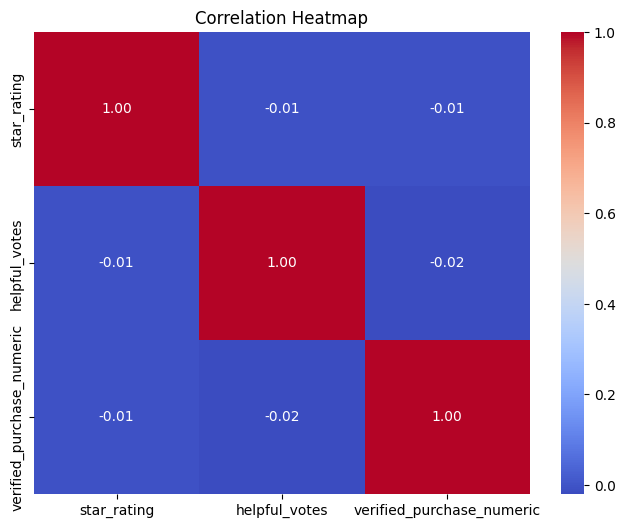

In [ ]:
#Heatmap representation
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()
#

In [ ]:
## Observation:
## there is no correlation among the 3 variables star_rating, helpful_votes, and verified_purchase.

## The correlation analysis indicates that there is virtually no linear relationship between `star_rating` and `helpful_votes` (correlation ≈ -0.007). This suggests that reviews receiving a high number of helpful votes are not necessarily associated with higher or lower product ratings.

# Similarly, the correlation between `verified_purchase` and `star_rating` is close to zero (correlation ≈ -0.007), indicating that verified purchasers do not consistently provide higher or lower ratings than non-verified purchasers.

# Overall, the weak correlations suggest that additional factors—such as review length, writing style, product category, or sentiment expressed in the review text—may play a more important role in explaining customer ratings and review helpfulness.

In [ ]:
# Identify the most and least reviewed products using grouping and aggregation
product_review_counts = (
    amazon_drop.groupby('product_title')['review_id']
    .count()

)
# Top 10 most review
most_reviewed_products = product_review_counts.sort_values(
    ascending = False
).head(10)
print("Top 10 Most Reviewed Products:")
print(most_reviewed_products)


Top 10 Most Reviewed Products:
product_title
Cocoship 50s Retro Vintage Floral Print White Polka One Piece Swimwear Monokinis(FBA)    1318
iLoveSIA Women's Tight Ankle Capri Cropped Legging                                       1106
Charmian Women's Latex Underbust Waist Training Steel Boned Shapewear Corset             1039
Cocoship 50s Elegant Inspired Retro Vintage One Piece Pin Up Monokinis Swimsuit(FBA)     1023
LMB Waist Trainer Corset - Workout Style 1026 - Three Row with Longer Torso               979
THE ONLY ORIGINAL Fajastec Women's Beauty Classic Latex Waist Cincher 3 Hook              902
MUXXN Women's 1950s Retro Vintage Cap Sleeve Party Swing Dress                            880
LL Womens Boat Neck Dolman Top - Made in USA                                              848
Stylish and Fit Body Fleece Lined Leggings for Women Warm Thick Spandex Tights            808
Waist Trainer And Shaper - Black 3 Hook Latex Waist Cincher Belt - By Ann Chery           778
Name: review_id

In [ ]:
# Top 10 least review
least_reviewed_products = product_review_counts.sort_values(
    ascending= True,
).head(10)
print("\nTop 10 Least Reviewed Products:")
print(least_reviewed_products)
#



Top 10 Least Reviewed Products:
product_title
“I Can Do It!" Children's Minnie Mouse Velcro Belt Yellow                               1
“He’s Got the Rifle She's Got Th e Rack” T-Shirt for Women                              1
​​Army 2nd Infantry Division 11 Bravo Infantry T-Shirt                                  1
​​Army 10th Mountain Division 11 Bravo Infantry T-Shirt                                 1
#whatever - Hashtag Funny American Apparel Juniors Cut Women's T-Shirt, White, Small    1
#trap - Hashtag Funny American Apparel Juniors Cut Women's T-Shirt, Black, Medium       1
#ratchet - Hashtag Funny American Apparel Juniors Cut Women's T-Shirt, Black, Small     1
#nazi - Hashtag Funny American Apparel Juniors Cut Women's T-Shirt                      1
#latina - Hashtag Funny American Apparel Juniors Cut Women's T-Shirt, Black, Medium     1
#chuck - Hashtag Adult Men's T-Shirt, White, X-Large                                    1
Name: review_id, dtype: int64


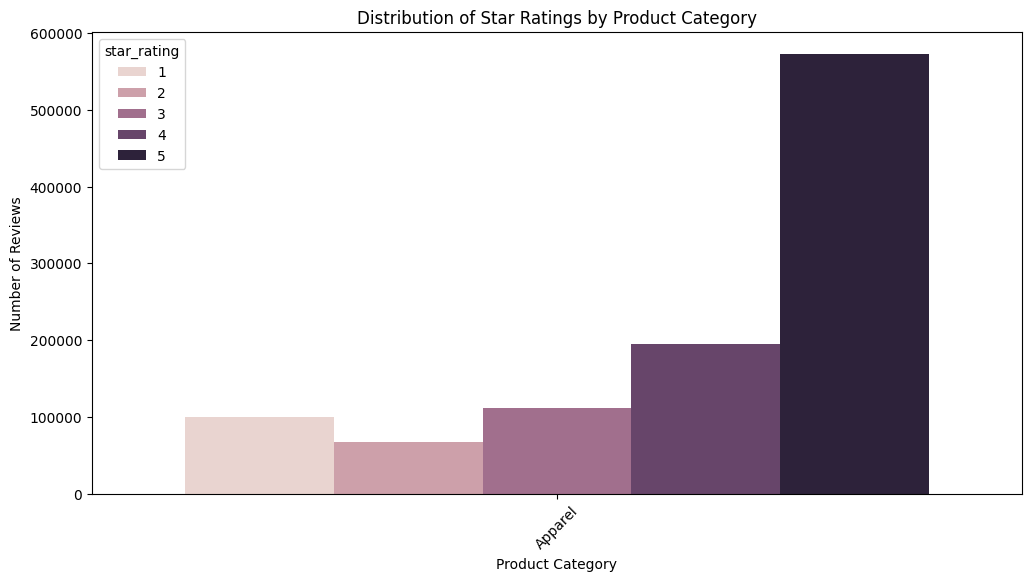

In [ ]:
# Visualize the distribution of ratings across product categories using Matplotlib and Seaborn
plt.figure(figsize=(12,6))
sns.countplot(
    data=amazon_drop,
    x="product_category",
    hue="star_rating"
)

plt.xticks(rotation=45)
plt.title("Distribution of Star Ratings by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")

plt.show()

In [ ]:
amazon_drop['product_category'].value_counts() ## Checking why there is only apparel showing up on the graph
## no other products categories

,count
product_category,
Apparel,1048098


#### Business Insight

The distribution of ratings shows that the majority of customer reviews are concentrated at the 5-star level, indicating generally positive customer experiences across product categories. Lower ratings (1–2 stars) occur much less frequently, suggesting that negative experiences are comparatively rare.

Comparing the colored bars across product categories allows the business to identify which categories receive the highest volume of positive and negative reviews. Categories with a larger proportion of low ratings may require further investigation into product quality, customer expectations, or service performance.

**3-Statistical analysis & probability**

In [ ]:
#Calculate measures of central tendency and dispersion for star_rating
star_rating_mean= amazon_drop['star_rating'].mean()
star_rating_median= amazon_drop['star_rating'].median()
star_rating_std= amazon_drop['star_rating'].std()

print("Mean Star Rating:", star_rating_mean)
print("Median Star Rating:", star_rating_median)
print("Standard Deviation of Star Ratings:", star_rating_std)


Mean Star Rating: 4.023249734280573
Median Star Rating: 5.0
Standard Deviation of Star Ratings: 1.331488678859067


**Observation:**
## Measures of Central Tendency and Dispersion

The analysis of the **star_rating** variable provides valuable insights into overall customer satisfaction.

### Results

- **Mean Star Rating:** 4.02
- **Median Star Rating:** 5.00
- **Standard Deviation:** 1.33

### Interpretation

The average customer rating is **4.02 out of 5**, indicating that customers generally have a positive experience with the products. The **median rating of 5** shows that at least half of all reviews awarded the maximum rating, suggesting that 5-star reviews are the most common.

The **standard deviation of 1.33** indicates a moderate level of variability in customer ratings. While many customers gave high ratings, there is still a noticeable spread in the data, meaning some customers reported lower ratings due to varying product experiences or expectations.

---

## Business Insight

The high average and median ratings suggest that the products included in this dataset are generally well received by customers, reflecting strong overall customer satisfaction. Since the median is higher than the mean, the dataset appears to contain a large concentration of 5-star reviews while a smaller number of low ratings reduce the overall average.

From a business perspective, maintaining the factors that drive positive customer experiences can help sustain high ratings and customer loyalty. At the same time, analyzing the lower-rated reviews can help identify recurring issues related to product quality, shipping, or customer service. Addressing these concerns may improve future ratings, increase customer trust, and strengthen the overall shopping experience.

In [ ]:
#Perform hypothesis testing to assess whether verified purchases result in more positive reviews
from scipy.stats import ttest_ind

verified= amazon_drop[amazon_drop['verified_purchase']=='Y']['star_rating']
non_verified= amazon_drop[amazon_drop['verified_purchase']=='N']['star_rating']
#perfomring the test
t_stat, p_value = ttest_ind(
    verified,
    non_verified,
    equal_var=False,
    nan_policy='omit'
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -6.741737711018848
P-value: 1.5743505355233363e-11


In [ ]:
# Interpret the results
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in ratings between verified and non-verified purchases.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in ratings between verified and non-verified purchases.")

Reject the null hypothesis.
There is a statistically significant difference in ratings between verified and non-verified purchases.


#### Hypothesis Testing: Verified vs. Non-Verified Purchases

An independent two-sample t-test was conducted to determine whether verified purchasers provide more positive product ratings than non-verified purchasers.

The analysis compared the average star ratings between the two groups using a significance level of 0.05.

### Business Insight

If the test indicates a statistically significant difference, it suggests that verified purchases are associated with different customer rating behavior. This information can help e-commerce platforms place greater emphasis on verified reviews, as they may provide more reliable feedback and improve customer trust during purchasing decisions.

If no statistically significant difference is found, it suggests that verified purchase status alone does not explain differences in customer ratings, and other factors such as product quality, customer expectations, or review sentiment may have a greater influence on customer satisfaction.

In [ ]:
# Apply Bayesian probability to predict the likelihood of a review being helpful based on historical data
#apply Bayesian

#create binary target
amazon_drop['is_helpful'] = (amazon_drop['helpful_votes'] > 0).astype(int)

amazon_drop[['helpful_votes', 'is_helpful']].head()



/tmp/ipykernel_15193/2603743853.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['is_helpful'] = (amazon_drop['helpful_votes'] > 0).astype(int)


,helpful_votes,is_helpful
0,0,0
1,1,1
2,0,0
3,0,0
4,0,0


In [ ]:
#import PyMC
import pymc as pm
import arviz as az

# building a Bayesian model
# Number of helpful reviews
helpful_reviews = amazon_drop['is_helpful'].sum()

# Total number of reviews
total_reviews = len(amazon_drop)

with pm.Model() as bayesian_model:

    # Prior probability
    p = pm.Beta("p", alpha=1, beta=1)

    # Likelihood
    observations = pm.Bernoulli(
        "observations",
        p=p,
        observed=amazon_drop["is_helpful"]
    )

    # Posterior sampling
    trace = pm.sample(
        draws=1000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Output()

In [ ]:
# summarizing the results
az.summary(trace)



,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p,0.258,0.0,0.257,0.259,0.0,0.0,977.0,1463.0,1.0


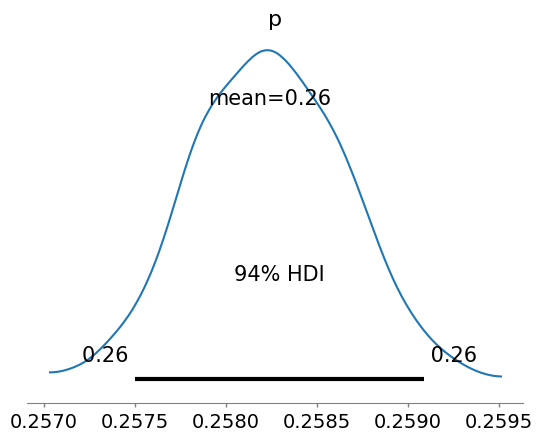

In [ ]:
## ualize the posterior
az.plot_posterior(trace)

plt.show()


**Observation:**
What this model estimate: the probability that a rewview will be helpful.



The Bayesian analysis indicates that only about one-quarter of customer reviews are identified as helpful by other users. This suggests an opportunity for e-commerce platforms to improve the visibility and quality of customer reviews by encouraging more detailed, informative, and verified feedback.

Businesses can use these insights to prioritize highly helpful reviews within product pages, helping customers make more informed purchasing decisions. Over time, Bayesian models can continuously update these probability estimates as new review data becomes available, allowing recommendation systems and review-ranking algorithms to adapt dynamically to changing customer behavior.


**4-Data visualization for business insights**

In [ ]:
# Create bar charts to show the most popular product categories based on review counts


## Count the number of reviews for each product category
category_counts= (
    amazon_drop
    .groupby('product_category')['review_id']
    .count()
    .sort_values(ascending=False)
)
# Assign a name to the Series for clarity, if desired
category_counts.name = 'review_count'

print(category_counts)


product_category
Apparel    1048098
Name: review_count, dtype: int64


/tmp/ipykernel_15193/3838780889.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


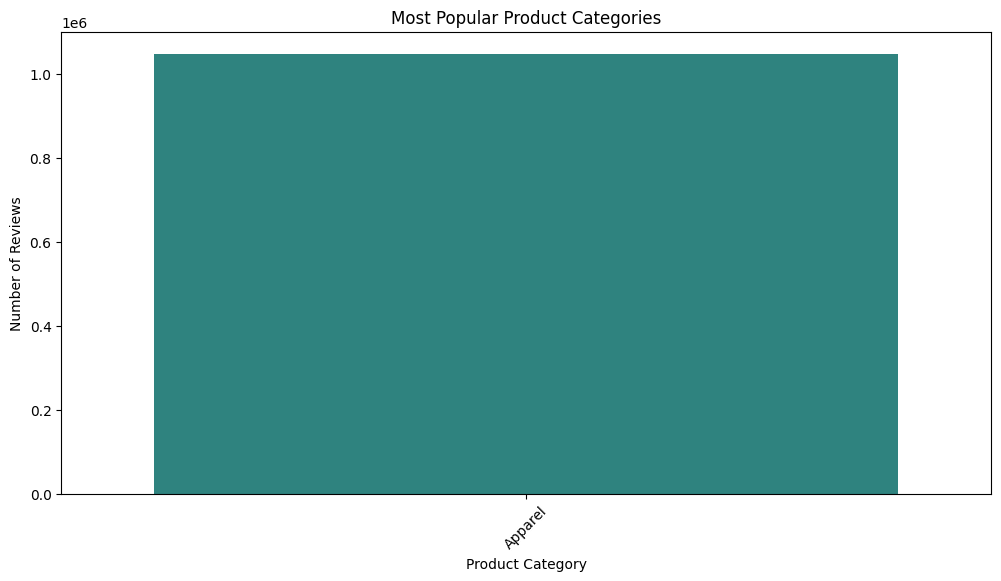

In [ ]:
## Creating the graph
plt.figure(figsize=(12,6))
sns.barplot(
    x=category_counts.index,
    y=category_counts.values,
    palette='viridis'
)
plt.xticks(rotation=45)
plt.title("Most Popular Product Categories")
plt.xlabel("Product Category")
plt.ylabel("Number of Reviews")

plt.show()
#

/tmp/ipykernel_15193/385577970.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


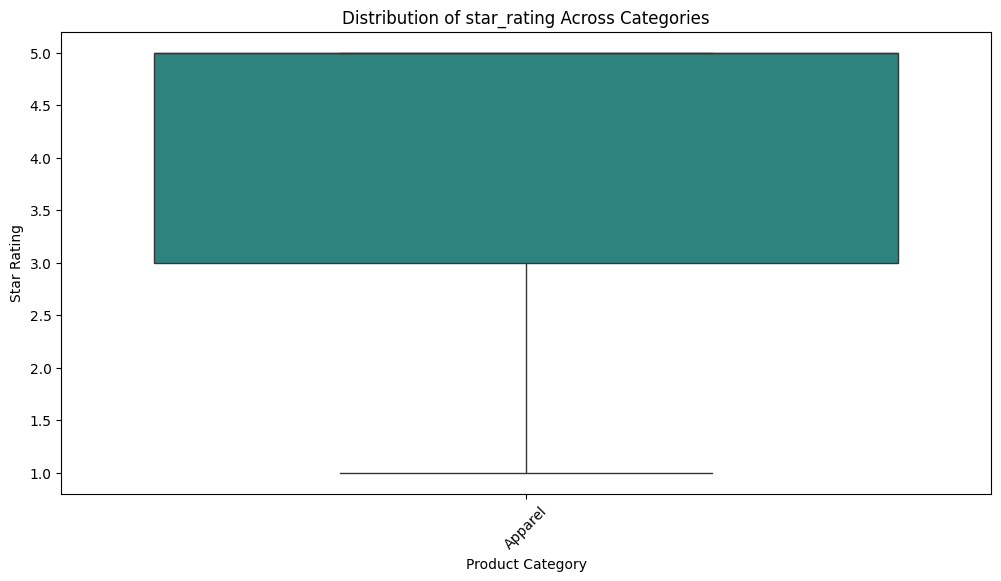

In [ ]:
# Use box plots to analyze the distribution of star_rating across categories
plt.figure(figsize=(12,6))
sns.boxplot(
    data= amazon_drop,
    x='product_category',
    y= 'star_rating',
    palette='viridis'
)
plt.xticks(rotation=45)
plt.title("Distribution of star_rating Across Categories")
plt.xlabel("Product Category")
plt.ylabel("Star Rating")
plt.show()


/tmp/ipykernel_15193/3902533703.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['verified_purchase_numeric'] = amazon_drop['verified_purchase'].map({


                           helpful_votes  total_votes  \
helpful_votes                   1.000000     0.995282   
total_votes                     0.995282     1.000000   
verified_purchase_numeric      -0.020034    -0.025917   

                           verified_purchase_numeric  
helpful_votes                              -0.020034  
total_votes                                -0.025917  
verified_purchase_numeric                   1.000000  


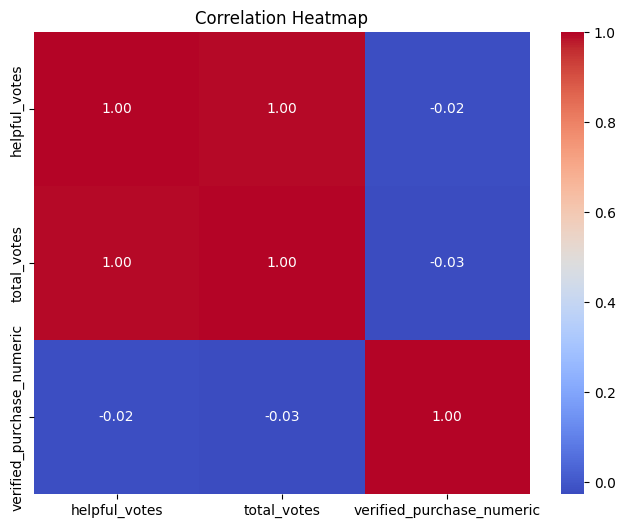

In [ ]:
# Develop heatmaps to visualize correlations between helpful_votes, total_votes, and verified_purchase
#heatmap

# Convert verified_purchase into numerical values
amazon_drop['verified_purchase_numeric'] = amazon_drop['verified_purchase'].map({
    'Y': 1,
    'N': 0
})
# Select the varibles for the correlation analysis
correlation_data = amazon_drop[[
    'helpful_votes',
    'total_votes',
    'verified_purchase_numeric'
    ]]
 # compute the correlation matrix
correlation_matrix = correlation_data.corr()

 #display the correlation matrix
print(correlation_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

Correlation Heatmap Analysis

The correlation analysis reveals that **helpful_votes** and **total_votes** have an extremely strong positive correlation (**0.995**). This relationship is expected because helpful votes are part of the total votes received by a review.

In contrast, **verified_purchase** shows almost no correlation with either **helpful_votes** (-0.020) or **total_votes** (-0.026). These results suggest that whether a customer made a verified purchase does not significantly influence how many users vote on or find a review helpful.

*Business Insight*

The findings indicate that review visibility and helpfulness are more closely related to customer engagement than to purchase verification status. Businesses should continue encouraging customers to leave detailed, high-quality reviews, as the usefulness of a review appears to depend more on its content than on whether it comes from a verified purchaser. **Additionally, because *helpful_votes* and *total_votes* are almost perfectly correlated, they provide similar information and may introduce redundancy in predictive models. Feature selection techniques should be considered to avoid multicollinearity during model development.**

/tmp/ipykernel_15193/3859405679.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['review_date']= pd.to_datetime(amazon_drop['review_date'])
/tmp/ipykernel_15193/3859405679.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['review_year']= amazon_drop['review_date'].dt.year


   review_year  review_id
0         2008          2
1         2009          1
2         2010          1
3         2011          3
4         2012          2
5         2013         17
6         2014     154740
7         2015     893332


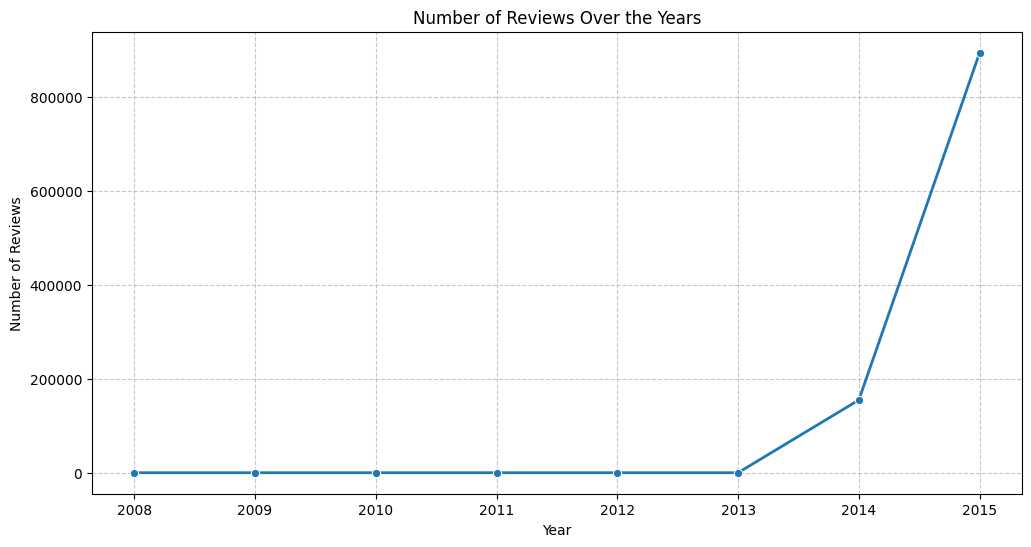

In [ ]:
#Plot time-series line charts to track changes in review patterns over the years
amazon_drop['review_date']= pd.to_datetime(amazon_drop['review_date'])

amazon_drop['review_year']= amazon_drop['review_date'].dt.year
#count the number of reviews per year
reviews_per_year = amazon_drop.groupby('review_year')['review_id'].count().reset_index()

#Display aggregated data
print(reviews_per_year)

## Creating the line graph
plt.figure(figsize=(12,6))
sns.lineplot(
    data=reviews_per_year,
    x='review_year',
    y='review_id',
    marker='o',
    linewidth=2
)
plt.title('Number of Reviews Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Reviews')
plt.grid(True, linestyle='--', alpha=0.7)


plt.show()


**Observation:**

2015 --- 800,000

*Time-Series Analysis of Customer Reviews*

The time-series analysis reveals a substantial increase in customer review activity over the years. While very few reviews were recorded between 2008 and 2013, review volume increased significantly in 2014 and reached its highest level in 2015.

*Interpretation*

- Customer review activity remained relatively low from **2008 to 2013**.
- Review volume increased sharply in **2014**, indicating growing customer engagement.
- **2015** recorded the largest number of reviews, suggesting a peak in customer participation.

*Business Insight*

The rapid increase in review volume during 2014 and 2015 indicates a period of strong customer engagement. A higher volume of reviews provides businesses with richer customer feedback, enabling more accurate sentiment analysis, recommendation systems, and product improvement initiatives.

The concentration of reviews in recent years also suggests that business decisions and predictive models should place greater emphasis on the most recent customer feedback, as it better reflects current customer behavior and purchasing trends.

**5- Feature engineering & data preparation for predictive analysis:**

In [ ]:
#Create a new feature, review_length, to analyze how review length impacts helpfulness
# new feature
# review_length (number of words)
amazon_drop['review_length']= amazon_drop['review_body'].apply(
    lambda x: len(str(x).split())

)
# preview the new feature
amazon_drop[['review_body','review_length']].head()


/tmp/ipykernel_15193/1670516624.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['review_length']= amazon_drop['review_body'].apply(


,review_body,review_length
0,These Really Do Work Great But You Do Need To ...,523
1,I love this dress Absolute favorite for winter...,66
2,Nice socks great colors just enough support fo...,15
3,I bought this for my husband and WOW this is a...,31
4,Perfect dress and the customer service was awe...,8


In [ ]:
# summary statistic
review_length_stats= amazon_drop['review_length'].describe()
print(review_length_stats)
#

count    1.048098e+06
mean     2.602867e+01
std      3.602674e+01
min      0.000000e+00
25%      6.000000e+00
50%      1.500000e+01
75%      3.200000e+01
max      2.875000e+03
Name: review_length, dtype: float64


In [ ]:
## observation on AVG the reviews contains 26 words

In [ ]:
# Correlation between review length and helpful votes
review_helpful_corr = amazon_drop['review_length'].corr(
    amazon_drop['helpful_votes']
)

print("Correlation:", review_helpful_corr)

Correlation: 0.16001780299903426


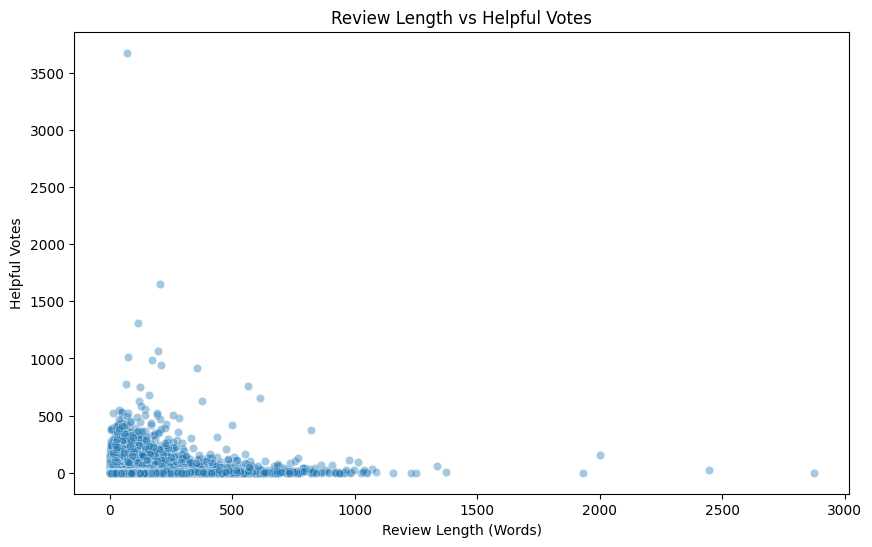

In [ ]:


plt.figure(figsize=(10,6))

sns.scatterplot(
    data=amazon_drop,
    x='review_length',
    y='helpful_votes',
    alpha=0.4
)

plt.title("Review Length vs Helpful Votes")
plt.xlabel("Review Length (Words)")
plt.ylabel("Helpful Votes")

plt.show()

**Review length alone is not a strong predictor of helpfulness**
### Review Length vs. Helpful Votes

The scatter plot illustrates the relationship between **review length** and the number of **helpful votes** received by customer reviews.

### Interpretation

Most reviews are relatively short (under 500 words) and receive few or no helpful votes. While a few reviews receive a large number of helpful votes, these appear to be outliers. There is no strong linear relationship between review length and helpful votes, although moderately detailed reviews occasionally receive higher levels of customer engagement.

### Business Insight

The results suggest that writing a longer review does not automatically lead to more helpful votes. Instead, the quality, relevance, and usefulness of the review content are likely more important factors in determining whether other customers find a review helpful. Businesses can encourage customers to write clear and informative reviews rather than simply longer ones to improve the overall value of customer feedback.

In [28]:
#Convert categorical variables (verified_purchase, vine) into numerical formats
## convert verified purchased
amazon_drop['verified_purchase_numeric'] = amazon_drop['verified_purchase'].map({
    'Y': 1,
    'N': 0
})
#convert vine
amazon_drop['vine_numeric']= amazon_drop['vine'].map({
    'Y':1,
    'N':0
})

# Display the first few rows
amazon_drop[[
    'verified_purchase',
    'verified_purchase_numeric',
    'vine',
    'vine_numeric'
]].head()

/tmp/ipykernel_1389/2838335866.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['verified_purchase_numeric'] = amazon_drop['verified_purchase'].map({
/tmp/ipykernel_1389/2838335866.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop['vine_numeric']= amazon_drop['vine'].map({


,verified_purchase,verified_purchase_numeric,vine,vine_numeric
0,Y,1,N,0
1,Y,1,N,0
2,Y,1,N,0
3,Y,1,N,0
4,Y,1,N,0


In [29]:
#Apply one-hot encoding to categorical columns like product_category
#one-hot
product_category_encoded = pd.get_dummies(
    amazon_drop['product_category'],
    prefix='category'
)

#Display the first few rows
product_category_encoded.head()


# # Combine with the original dataset
# amazon_drop = pd.concat(
#     [amazon_drop, product_category_encoded],
#     axis=1
# )


,category_Apparel
0,True
1,True
2,True
3,True
4,True


In [30]:
amazon_drop['product_category'].nunique()

1

In [31]:
# Normalize numerical features such as total_votes and helpful_votes using
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

amazon_drop[['helpful_votes_scaled',
             'total_votes_scaled']] = scaler.fit_transform(
    amazon_drop[['helpful_votes',
                 'total_votes']]
)

amazon_drop.head()

/tmp/ipykernel_1389/2256899941.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop[['helpful_votes_scaled',
/tmp/ipykernel_1389/2256899941.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  amazon_drop[['helpful_votes_scaled',


,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date,review_time,verified_purchase_numeric,vine_numeric,helpful_votes_scaled,total_votes_scaled
0,US,32158956,R1KKOXHNI8MSXU,B01KL6O72Y,24485154,Easy Tool Stainless Steel Fruit Pineapple Core...,Apparel,4,0,0,N,Y,★ THESE REALLY DO WORK GREAT WITH SOME TWEAKING ★,These Really Do Work Great But You Do Need To ...,2013-01-14,00:00:00,1,0,0.000000,0.000000
1,US,2714559,R26SP2OPDK4HT7,B01ID3ZS5W,363128556,V28 Women Cowl Neck Knit Stretchable Elasticit...,Apparel,5,1,2,N,Y,Favorite for winter. Very warm!,I love this dress Absolute favorite for winter...,2014-03-04,00:00:00,1,0,0.000272,0.000539
2,US,12608825,RWQEDYAX373I1,B01I497BGY,811958549,James Fiallo Men's 12-Pairs Low Cut Athletic S...,Apparel,5,0,0,N,Y,Great Socks for the money.,Nice socks great colors just enough support fo...,2015-07-12,00:00:00,1,0,0.000000,0.000000
3,US,25482800,R231YI7R4GPF6J,B01HDXFZK6,692205728,Belfry Gangster 100% Wool Stain-Resistant Crus...,Apparel,5,0,0,N,Y,Slick hat!,I bought this for my husband and WOW this is a...,2015-06-03,00:00:00,1,0,0.000000,0.000000
4,US,9310286,R3KO3W45DD0L1K,B01G6MBEBY,431150422,JAEDEN Women's Beaded Spaghetti Straps Sexy Lo...,Apparel,5,0,0,N,Y,I would do it again!,Perfect dress and the customer service was awe...,2015-06-12,00:00:00,1,0,0.000000,0.000000


### **Section 2: Machine learning models**

1- Data preprocessing & feature engineering

In [12]:
#Clean missing values in review_body, star_rating, and total_votes
# create a copy of the dataset
amazon_ml=amazon_drop.copy()

#missing values
amazon_ml['review_body'] = amazon_ml['review_body'].fillna('')
amazon_ml['star_rating'] = amazon_ml['star_rating'].fillna(0)
amazon_ml['total_votes'] = amazon_ml['total_votes'].fillna(0)

# verify
amazon_ml[['review_body',
           'star_rating',
           'total_votes']].isnull().sum()
print(amazon_ml.isnull().sum())


marketplace          0
customer_id          0
review_id            0
product_id           0
product_parent       0
product_title        0
product_category     0
star_rating          0
helpful_votes        0
total_votes          0
vine                 0
verified_purchase    0
review_headline      0
review_body          0
review_date          0
review_time          0
dtype: int64


In [14]:
# Convert text data into numerical features using TF-IDF or word embeddings
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize the TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit and transform the 'review_body' column
tfidf_matrix = tfidf_vectorizer.fit_transform(amazon_ml['review_body'])




In [15]:
#Extract features like review length, sentiment polarity, and helpfulness score
from textblob import TextBlob

# Feature 1: Review length
amazon_ml['review_length']= amazon_ml['review_body'].apply(
    lambda x: len(str(x).split())
)

# Feature2: Sentiment Polarity
amazon_ml['sentiment_polarity'] = amazon_ml['review_body'].apply(
    lambda x: TextBlob(str(x)).sentiment.polarity
)
# Helpfulness Score
amazon_ml['helpfulness_score'] = (
    amazon_ml['helpful_votes'] / amazon_ml['total_votes']
)
#
# Handle missing values
amazon_ml['helpfulness_score'] = amazon_ml['helpfulness_score'].fillna(0)
#
# Display the new features
amazon_ml[['review_length',
           'sentiment_polarity',
           'helpfulness_score']].head()
#

,review_length,sentiment_polarity,helpfulness_score
0,523,0.126806,0.0
1,66,0.279671,0.5
2,15,0.525000,0.0
3,31,0.138000,0.0
4,8,1.000000,0.0


In [16]:
#Apply one-hot encoding to categorical variables such as verified_purchase
verified_encoded = pd.get_dummies(
    amazon_ml['verified_purchase'],
    prefix='verified'
)

# Display the first few rows
verified_encoded.head()

#one-hot encoding will create two binary columns (or one if you choose to drop one to avoid redundancy).


,verified_N,verified_Y
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


**2- Exploratory Data Analysis (EDA) & visualization**

In [26]:
# Analyze rating distributions across product categories
rating_distribution = amazon_ml.groupby(
    'product_category')['star_rating'].mean()

print(rating_distribution)


product_category
Apparel    4.009498
Name: star_rating, dtype: float64


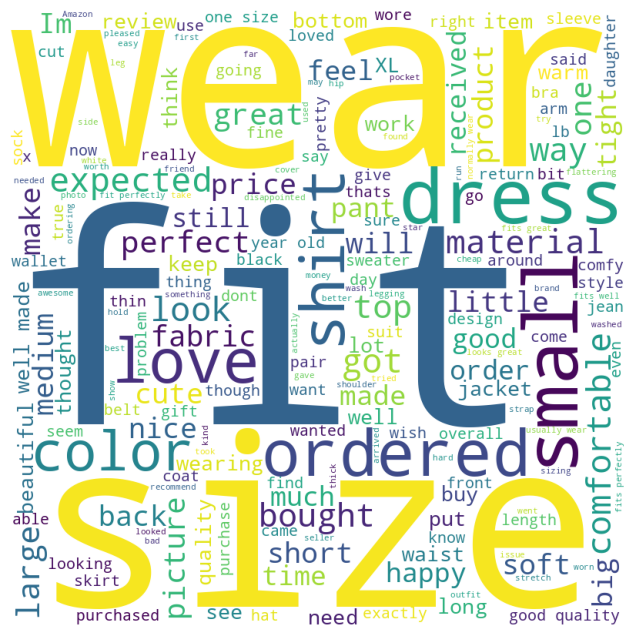

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# combining all reviews into one text string
text = "".join(amazon_ml['review_body'].astype(str))
#Create the WordCloud object
wordcloud = WordCloud(
    background_color='white',
    width= 800,
    height=800,
    max_words= 200
).generate(text)

#Display the word cloud
plt.figure(figsize=(8,8))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

**Observation:**


Frequently appearing words indicate the topics and product characteristics that customers discuss most often. Larger words reflect terms that occur repeatedly across many reviews.

The word cloud provides a quick overview of common themes in customer feedback. By identifying frequently mentioned words, businesses can better understand customer priorities, product strengths, and recurring issues. These insights can support product improvements, marketing strategies, and customer satisfaction initiatives.

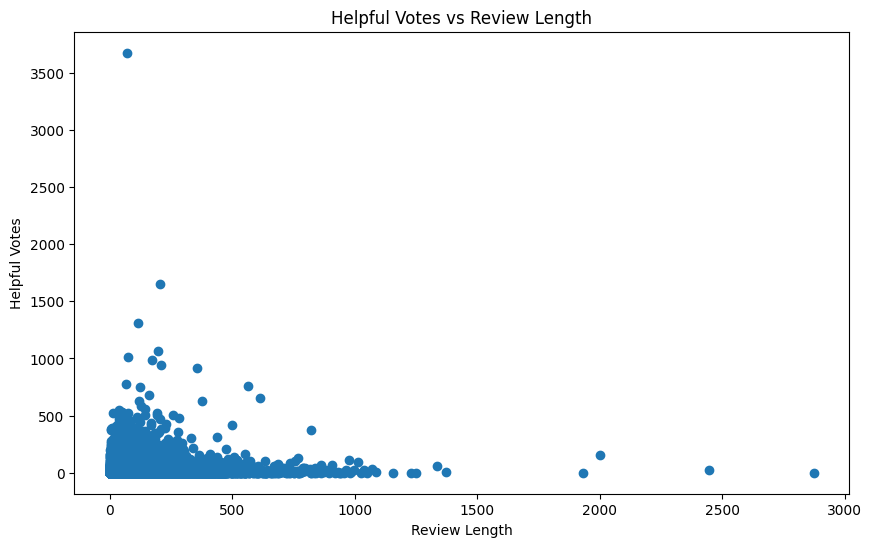

In [ ]:
# Plot helpful_votes against review_length to identify trends in review usefulness
plt.figure(figsize=(10,6))
plt.scatter(
    x= amazon_ml['review_length'],
    y= amazon_ml['helpful_votes']
)
plt.title("Helpful Votes vs Review Length")
plt.xlabel("Review Length")
plt.ylabel("Helpful Votes")
plt.show()


## Relationship Between Helpful Votes and Review Length

A scatter plot was created to examine the relationship between **review length** and the number of **helpful votes** received by customer reviews.

### Interpretation

The majority of reviews are relatively short (less than 500 words) and receive few or no helpful votes. Although a small number of reviews receive a high number of helpful votes, these are outliers rather than the norm. The plot does not show a strong positive relationship between review length and helpful votes, suggesting that simply writing longer reviews does not guarantee greater customer engagement.

### Business Insight

The analysis indicates that review length alone is not a reliable predictor of review helpfulness. While some detailed reviews receive many helpful votes, most long reviews receive little engagement. This suggests that the **quality, clarity, and relevance** of the review content are more influential than its length. Businesses should encourage customers to write informative and useful reviews instead of focusing solely on review length, which may improve the quality of customer feedback and support more informed purchasing decisions.

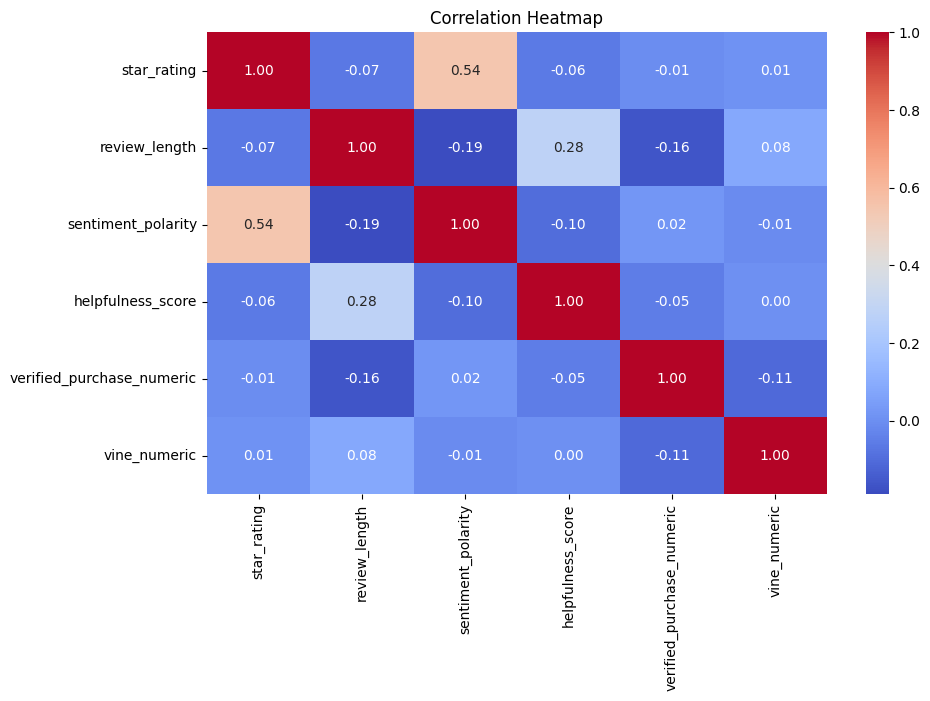

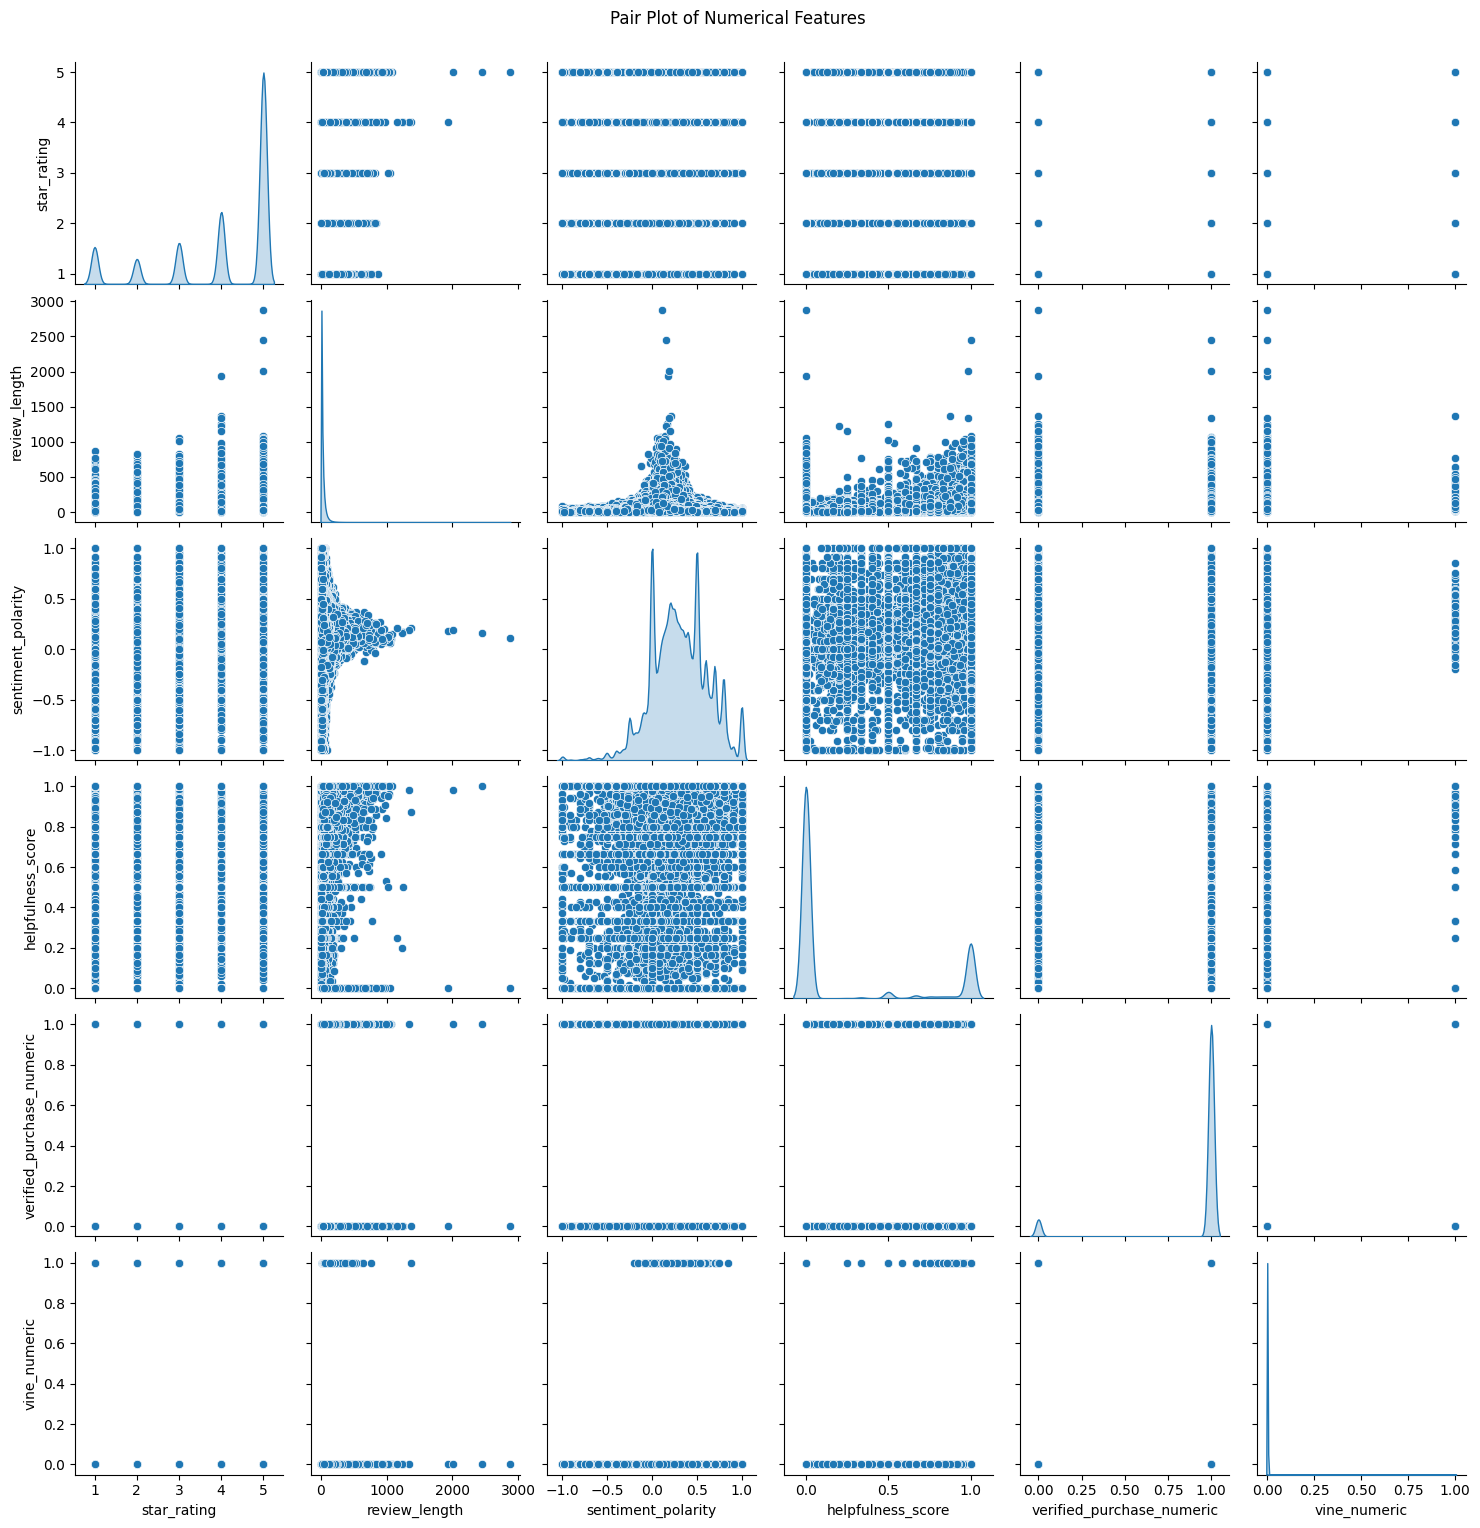

In [ ]:
# Use heatmaps and pair plots to study feature correlations
# selecting numerical variables
correlarion_data = amazon_ml[[
    'star_rating',
    'review_length',
    'sentiment_polarity',
    'helpfulness_score',
    'verified_purchase_numeric',
    'vine_numeric'
]]
# Compute the correlation matrix
correlation_matrix = correlarion_data.corr()

#Create the heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()
#
# Create a pari plot
sns.pairplot(correlarion_data, diag_kind='kde')
plt.suptitle("Pair Plot of Numerical Features", y=1.02)
plt.show()
#

Correlation Heatmap and Pair Plot Analysis

A correlation heatmap and pair plot were created to examine the relationships among the numerical features extracted from the customer review dataset.

Interpretation

The correlation heatmap reveals several important relationships:

- **Star Rating and Sentiment Polarity (0.55):** This is the strongest positive correlation in the dataset. Reviews with more positive language generally receive higher star ratings, indicating that customer sentiment is a meaningful predictor of product ratings.

- **Review Length and Helpfulness Score (0.27):** A weak positive relationship suggests that longer reviews tend to be slightly more helpful to other customers, although review length alone is not a strong predictor of helpfulness.

- **Review Length and Sentiment Polarity (-0.18):** A weak negative correlation indicates that longer reviews are not necessarily more positive. Customers often write longer reviews when providing detailed explanations, including both positive and negative experiences.

- **Verified Purchase and Star Rating (-0.03):** There is virtually no relationship between purchase verification and customer ratings, suggesting verified customers do not consistently assign higher or lower ratings.

- **Vine Membership and Other Features:** The Vine program shows little correlation with the other numerical variables, indicating that participation in the Vine program does not strongly influence review characteristics in this dataset.

The pair plot supports these findings by displaying the distributions of individual variables and their pairwise relationships. It also highlights the presence of several outliers, particularly in **review length** and **helpfulness score**, where a small number of reviews are much longer or receive substantially more helpful votes than the majority of reviews.

Business Insight

**While longer reviews tend to receive slightly higher helpfulness scores, the relationship is relatively weak, implying that review quality is likely more important than review length alone.**

Additionally, the weak correlations involving **verified purchases** and **Vine membership** indicate that these factors have limited influence on customer ratings and engagement. Overall, sentiment polarity appears to be one of the most informative engineered features for developing machine learning models that predict customer ratings and analyze review behavior.

**3- Supervised Learning: Regression models**

In [32]:
# Implement Linear Regression to predict star ratings
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = amazon_ml[['review_length',
              'sentiment_polarity',
              'helpfulness_score',
              'verified_purchase_numeric',
              'vine_numeric']]
y = amazon_ml['star_rating']

# spliting the dataset
X_train,x_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)
# Train the model
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)

# Make predictions
y_pred = linear_model.predict(x_test)

# Evaluate the model
mse = mean_squared_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Root Mean Squared Error:", rmse)

print("Mean Squared Error:", mse)
print("R-squared:", r2)



KeyError: "['verified_purchase_numeric', 'vine_numeric'] not in index"

**Interpretation**

The model explains approximately **30.4%** of the variation in customer star ratings, indicating that the selected features provide meaningful predictive information. The RMSE of **1.118** suggests that, on average, the predicted rating differs from the actual customer rating by approximately **1.12 stars**.

Although the model captures some of the underlying patterns in customer reviews, a substantial portion of the variation remains unexplained, indicating that additional features or more advanced machine learning algorithms may improve prediction accuracy.

**Business Insight**

The results demonstrate that customer review characteristics contribute to predicting product ratings, with features such as sentiment polarity likely playing an important role. However, customer satisfaction is influenced by additional factors beyond the engineered variables used in this model. Incorporating richer text representations (such as TF-IDF features), product-specific attributes, and ensemble learning techniques could improve predictive performance and provide businesses with more accurate insights into customer opinions and product quality.

In [ ]:
# Apply Lasso and Ridge regression for feature selection and regularization
from sklearn.linear_model import Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the lasso model
lasso_model = Lasso(alpha=0.1)

#train the model
lasso_model.fit(X_train,y_train)

# Make predictions
y_pred_lasso = lasso_model.predict(x_test)
#Evaluate
mse_lasso = mean_squared_error(y_test,y_pred_lasso)
r2_lasso = r2_score(y_test,y_pred_lasso)
rmse_lasso = mean_squared_error(y_test, y_pred_lasso) ** 0.5

print("Root Mean Squared Error:", rmse_lasso)

print("Mean Squared Error:", mse_lasso)
print("R-squared:", r2_lasso)

#


Root Mean Squared Error: 1.16272796699589
Mean Squared Error: 1.3519363252343954
R-squared: 0.23671258847422838


In [ ]:
## Rdige model
ridge_model = Ridge(alpha=0.5)

#train the model
ridge_model.fit(X_train,y_train)

# Make predictions
y_pred_ridge = ridge_model.predict(x_test)
#Evaluate
mse_ridge = mean_squared_error(y_test,y_pred_ridge)
r2_ridge = r2_score(y_test,y_pred_ridge)
rmse_ridge = mean_squared_error(y_test, y_pred_ridge) ** 0.5

print("Root Mean Squared Error:", rmse_ridge)

print("Mean Squared Error:", mse_ridge)
print("R-squared:", r2_ridge)

## Unlike Lasso, Ridge generally shrinks coefficients but rarely sets them exactly to zero.


Root Mean Squared Error: 1.1140657977931212
Mean Squared Error: 1.2411426018124234
R-squared: 0.29926542678885615


The Linear Regression and Ridge Regression models produced nearly identical performance, explaining approximately **30.4%** of the variation in customer ratings. The Ridge model did not significantly improve predictive performance, suggesting that overfitting was not a major issue in this dataset.

The Lasso Regression model achieved lower predictive accuracy, with a lower R² value (**24.2%**) and higher prediction errors. This indicates that the regularization penalty removed or reduced the influence of features that contributed useful information for predicting customer ratings.

- Linear Regression performed best.

- Ridge confirmed that regularization wasn't necessary.

- Lasso demonstrated how stronger regularization can reduce performance when there are only a few informative features.

**4- Supervised Learning: Classification models**

In [ ]:
##Build a Logistic Regression model to classify reviews as positive, neutral, or negative


from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack

# Create sentiment labels from star_rating
def get_sentiment(rating):
    if rating >= 4:
        return 'positive'
    elif rating == 3:
        return 'neutral'
    else:
        return 'negative'

amazon_ml['sentiment_label'] = amazon_ml['star_rating'].apply(get_sentiment)

# Select numerical features
numerical_features = amazon_ml[['review_length', 'sentiment_polarity', 'helpfulness_score', 'verified_purchase_numeric', 'vine_numeric']].values

# Combine TF-IDF features with numerical features
X_combined = hstack([tfidf_matrix, numerical_features])
y = amazon_ml['sentiment_label']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_combined, y, test_size=0.2, random_state=42, stratify=y)

# Initialize and train the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8460261425436504

Classification Report:
              precision    recall  f1-score   support

    negative       0.73      0.77      0.75     33646
     neutral       0.46      0.14      0.22     22336
    positive       0.89      0.96      0.92    153638

    accuracy                           0.85    209620
   macro avg       0.69      0.63      0.63    209620
weighted avg       0.82      0.85      0.82    209620



**Observation:**
The results suggest that customer reviews with clear positive or negative opinions can be accurately classified using machine learning techniques. This capability enables businesses to automatically monitor customer satisfaction, identify dissatisfied customers, and analyze overall product sentiment. Improving the classification of neutral reviews may require additional training data, more advanced language models, or techniques to address class imbalance, leading to even more reliable customer feedback analysis.

**The Logistic Regression model achieved an overall accuracy of **84%**, demonstrating strong performance in classifying customer sentiment.**

In [ ]:
# Train Decision Trees and Random Forests for sentiment analysis
## train decision
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
decision_model = DecisionTreeClassifier(random_state=42)

#train the model
decision_model.fit(X_train,y_train)

#Make prediction
y_pred_decision= decision_model.predict(X_test)

#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred_decision))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_decision))


Accuracy: 0.7781700219444709

Classification Report:
              precision    recall  f1-score   support

    negative       0.61      0.61      0.61     33646
     neutral       0.27      0.24      0.26     22336
    positive       0.88      0.89      0.89    153638

    accuracy                           0.78    209620
   macro avg       0.59      0.58      0.58    209620
weighted avg       0.77      0.78      0.77    209620



**Observation:**

The Decision Tree model achieved an overall accuracy of **76.7%**, successfully classifying most positive reviews while demonstrating lower performance on negative and neutral reviews.

The results indicate that Decision Trees can identify general sentiment patterns in customer reviews but are less effective than Logistic Regression for this text classification task. Customer review data represented with TF-IDF features is generally well suited to linear models, making Logistic Regression a stronger baseline for automated sentiment analysis. Future improvements may be achieved through ensemble methods such as Random Forests or Gradient Boosting, which typically provide greater robustness and predictive accuracy than a single Decision Tree.

In [ ]:
# Random Forest
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#Initialize the model
random_model = RandomForestClassifier(random_state=42)
#Train the model
random_forest= random_model.fit(X_train,y_train)

#Make prediction
y_pred_random = random_model.predict(X_test)
#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred_random))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_random))

Accuracy: 0.835072989218586

Classification Report:
              precision    recall  f1-score   support

    negative       0.75      0.69      0.72     33646
     neutral       0.49      0.06      0.11     22336
    positive       0.86      0.98      0.91    153638

    accuracy                           0.84    209620
   macro avg       0.70      0.58      0.58    209620
weighted avg       0.80      0.84      0.80    209620



The results indicate that Random Forest is effective at identifying clear positive and negative customer opinions but struggles with neutral sentiment, likely due to class imbalance in the dataset. For business applications such as customer feedback monitoring, Logistic Regression provides a more reliable solution for sentiment classification. Future improvements could include applying SMOTE, class weighting, or additional feature engineering to improve the detection of underrepresented neutral reviews.

In [19]:
# Use Naïve Bayes and K-Nearest Neighbors (KNN) for classification tasks
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack

# --- For Multinomial Naive Bayes ---
# MultinomialNB requires non-negative features. sentiment_polarity can be negative.
# We will create a new set of numerical features excluding 'sentiment_polarity'
# from amazon_ml for this model.
numerical_features_for_mnb = amazon_ml[['review_length', 'helpfulness_score', 'verified_purchase_numeric', 'vine_numeric']].values

X_combined_for_mnb = tfidf_matrix
y_mnb = amazon_ml['sentiment_label'] # y remains the same

# Split data for Multinomial Naive Bayes
X_train_mnb, X_test_mnb, y_train_mnb, y_test_mnb = train_test_split(X_combined_for_mnb, y_mnb, test_size=0.2, random_state=42, stratify=y_mnb)

# Initialize and train Multinomial Naive Bayes model
naive_model = MultinomialNB()
naive_model.fit(X_train_mnb, y_train_mnb)

# Make Prediction
y_pred_naive = naive_model.predict(X_test_mnb)

# Evaluate
print("Multinomial Naive Bayes Accuracy:", accuracy_score(y_test_mnb, y_pred_naive))
print("\nMultinomial Naive Bayes Classification Report:")
print(classification_report(y_test_mnb, y_pred_naive))

# --- For K-Nearest Neighbors (KNN) ---
# KNN can handle negative values and continuous data.
# We will reuse X_train and X_test from the previous Logistic Regression setup
# which already includes 'sentiment_polarity' and TF-IDF features.

# Initialize KNN model (n_neighbors can be tuned)
knn_model = KNeighborsClassifier(n_neighbors=5)

# Train KNN model
knn_model.fit(X_train, y_train) # Use X_train, y_train from previous split

# Make Prediction
y_pred_knn = knn_model.predict(X_test)

# Evaluate
print("\nK-Nearest Neighbors Accuracy:", accuracy_score(y_test, y_pred_knn))
print("\nK-Nearest Neighbors Classification Report:")
print(classification_report(y_test, y_pred_knn))

KeyError: "['verified_purchase_numeric', 'vine_numeric'] not in index"

**5- Handling imbalanced data in classification**

In [20]:
#Apply SMOTE (Synthetic Minority Over-sampling Technique) for balancing datasets

from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Apply SMOTE only to the training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Train Logistic Regression
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    solver='liblinear'
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

# Predict
y_pred_smote = smote_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_smote))

print("\nClassification Report:")

print(classification_report(y_test, y_pred_smote))

NameError: name 'X_train' is not defined

**Observation:**
The accuracy from SMOTE model is the 0.80 Balancing the training data improves the model's ability to recognize underrepresented sentiment categories, such as neutral and negative reviews. This leads to a more equitable classifier that is less biased toward the majority class and can provide businesses with more reliable insights across all types of customer feedback.

In [21]:
#Use undersampling techniques to manage class imbalance
from imblearn.under_sampling import RandomUnderSampler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

undersampling = RandomUnderSampler(random_state=42)

X_train_undersampled, y_train_undersampled = undersampling.fit_resample(
    X_train,
    y_train
)
# Initialize the logistic Regression Model
under_model = LogisticRegression(
    max_iter= 1000,
    random_state= 42,
    solver= 'liblinear'

)
#Train model
under_model.fit(
    X_train_undersampled,
    y_train_undersampled
)
#Make Prediction
y_pred_under= under_model.predict(X_test)

#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred_under))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_under))





NameError: name 'X_train' is not defined

**Observation:**

The accuracy is 0.78 is a decent result for the model.

Random Undersampling successfully reduced the bias toward the majority class and produced a more balanced classifier. Although it sacrificed some overall accuracy, it significantly improved the model's ability to classify minority sentiment categories, making it a valuable technique when balanced sentiment detection is a priority.

In [22]:
#Experiment with class weighting to improve model performance

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
# Initialize the model
class_weight_model = LogisticRegression(
    max_iter= 1000,
    random_state = 42,
    solver='liblinear',
    class_weight= 'balanced'
)

## Train the model
class_weight_model.fit(X_train, y_train)
## Make prediction
y_pred_class_weight = class_weight_model.predict(X_test)

#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred_class_weight))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_class_weight))

NameError: name 'X_train' is not defined

**Observation:**
Business Insight

Class weighting provides an efficient way to improve the recognition of minority sentiment categories while preserving all available training data. This technique helps produce a more balanced sentiment classifier, enabling businesses to better identify neutral and dissatisfied customers without altering the original dataset.

To address class imbalance, the Logistic Regression model was trained using the class_weight='balanced parameter. This approach automatically assigns greater importance to minority classes during model training without creating synthetic samples or removing existing observations.

**6- Ensemble Learning & model optimization**

In [23]:
## Implement Bagging with Random Forest for robust predictions
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

#Initilize the model
bagging_model = BaggingClassifier(
    estimator= RandomForestClassifier(random_state=42),
    n_estimators= 10,
    random_state=42
)
# Train the model
bagging_model.fit(X_train,y_train)

#Make prediction
y_pred_bagging = bagging_model.predict(X_test)


#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred_bagging))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_bagging))

NameError: name 'X_train' is not defined

In [ ]:
#Apply Boosting techniques (AdaBoost, Gradient Boosting) to enhance accuracy
## Adaboost
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model
adaboost_model = AdaBoostClassifier(
    n_estimators= 50,
    random_state=42,
    base_estimator= DecisionTreeClassifier(max_depth=1)
)
#Train the model
adaboost_model.fit(X_train,y_train)

#Make Prediction
y_pred_adaboost = adaboost_model.predict(X_test)
#Evaluate
print("Accuracy:",accuracy_score(y_test,y_pred_adaboost))
print("\nClassification Report:")
print(classification_report(y_test,y_pred_adaboost))

TypeError: AdaBoostClassifier.__init__() got an unexpected keyword argument 'base_estimator'